In [1]:
!pip install requests beautifulsoup4 pandas lxml -q


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
soup = BeautifulSoup(response.text, "html.parser")

In [5]:
books = soup.find_all("article", class_="product_pod")

print("Total Books Found:", len(books))

Total Books Found: 20


In [6]:
titles = []
prices = []
ratings = []

for book in books:

    title = book.h3.a["title"]

    price = book.find("p", class_="price_color").text

    rating = book.p["class"][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

In [7]:
df = pd.DataFrame({
    "Book Title": titles,
    "Price": prices,
    "Rating": ratings
})

df.head()

,Book Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [8]:
print(df.info())

print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Book Title  20 non-null     object
 1   Price       20 non-null     object
 2   Rating      20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes
None
                  Book Title    Price Rating
count                     20       20     20
unique                    20       20      5
top     A Light in the Attic  Â£51.77    One
freq                       1        1      6


In [9]:
df.to_csv(
    "books_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [10]:
from google.colab import files

files.download("books_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

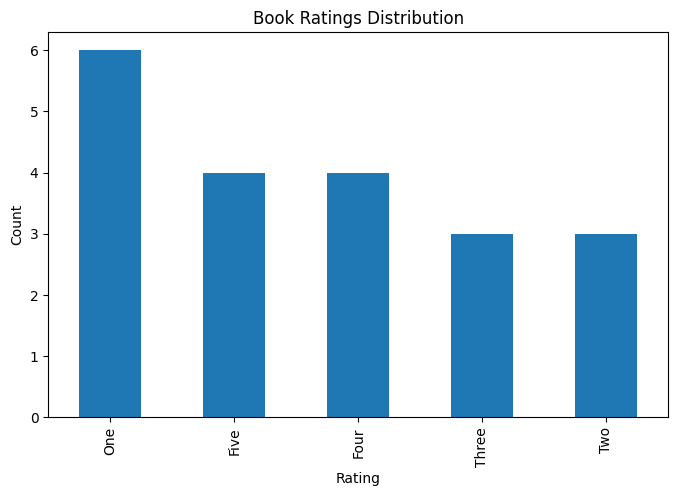

In [11]:
import matplotlib.pyplot as plt

rating_count = df["Rating"].value_counts()

plt.figure(figsize=(8,5))

rating_count.plot(kind="bar")

plt.title("Book Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

In [13]:
df["Price"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .astype(float)
)

print("Average Price:", df["Price"].mean())
print("Highest Price:", df["Price"].max())
print("Lowest Price:", df["Price"].min())


Average Price: 38.048500000000004
Highest Price: 57.25
Lowest Price: 13.99


In [14]:
df.sort_values(
    by="Price",
    ascending=False
).head(10)

,Book Title,Price,Rating
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three
4,Sapiens: A Brief History of Humankind,54.23,Five
1,Tipping the Velvet,53.74,One
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five
9,The Black Maria,52.15,One
0,A Light in the Attic,51.77,Three
18,Libertarianism for Beginners,51.33,Two
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
19,It's Only the Himalayas,45.17,Two


In [15]:
df.head(10)

,Book Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five
5,The Requiem Red,22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four
9,The Black Maria,52.15,One


In [16]:
df.to_csv(
    "books_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [17]:
from google.colab import files

files.download("books_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>